# MAST3R-SPoC 特征提取训练

## 概述
- **基础模型**: MAST3R backbone（croco 预训练权重）
- **训练方式**: SPoC（Sum-Pooled Convolutional features）：对 MAST3R 特征图空间维度求和池化得到全局描述子
- **与 ASMK 区别**: SPoC 更简单直接——全局求和池化，无选择性匹配核；速度更快但判别力略低于 ASMK
- **损失函数**: 对比损失（contrastive loss）
- **输出**: 全局 SPoC 描述子
- **模型保存**: 每 epoch / 最佳轮次保存完整模型权重

## 1. 环境配置与超参数

In [1]:
import os, math, time, json, copy
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.utils.checkpoint import checkpoint as torch_checkpoint
from torchvision import transforms
from PIL import Image
from tqdm import tqdm
from matplotlib import pyplot as plt

os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'
os.environ['HF_HOME'] = '../checkpoints'

# ── 路径配置 ──
IMAGE_ROOT = r'../image-matching-challenge-2025/train'
CHECKPOINT_DIR = r'../checkpoints/mast3r_spoc'
MAST3R_CHECKPOINT = '../models/MASt3R_ViTLarge_BaseDecoder_512_catmlpdpt_metric.pth'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# ── 下载 MAST3R 预训练权重（支持断点续传）──
def download_mast3r_checkpoint(url, dest_path, chunk_size=8*1024*1024):
    import urllib.request
    dest_path = os.path.abspath(dest_path)
    os.makedirs(os.path.dirname(dest_path), exist_ok=True)
    req = urllib.request.Request(url, method='HEAD')
    with urllib.request.urlopen(req, timeout=30) as resp:
        total_size = int(resp.headers.get('Content-Length', 0))
    print(f'Remote file size: {total_size / (1024**3):.1f} GB')
    downloaded = 0
    if os.path.exists(dest_path):
        downloaded = os.path.getsize(dest_path)
        if downloaded >= total_size:
            print(f'File already complete: {dest_path}')
            return
        elif downloaded > 0:
            print(f'Resuming from {downloaded / (1024**3):.2f} GB / {total_size / (1024**3):.2f} GB')
    mode = 'ab' if downloaded > 0 else 'wb'
    req = urllib.request.Request(url)
    if downloaded > 0:
        req.add_header('Range', f'bytes={downloaded}-')
    max_retries = 3
    for attempt in range(max_retries):
        try:
            with urllib.request.urlopen(req, timeout=60) as resp:
                with open(dest_path, mode) as f:
                    while True:
                        chunk = resp.read(chunk_size)
                        if not chunk: break
                        f.write(chunk)
                        downloaded += len(chunk)
                        pct = downloaded / total_size * 100
                        print(f'\r  Downloading... {downloaded / (1024**3):.2f} / {total_size / (1024**3):.2f} GB ({pct:.1f}%)', end='', flush=True)
            print(f'\nDownload complete: {dest_path}')
            return
        except Exception as e:
            print(f'\nDownload failed (attempt {attempt+1}/{max_retries}): {e}')
            if attempt < max_retries - 1:
                time.sleep(3)
                if os.path.exists(dest_path): downloaded = os.path.getsize(dest_path)
                mode = 'ab' if downloaded > 0 else 'wb'
                req = urllib.request.Request(url)
                if downloaded > 0: req.add_header('Range', f'bytes={downloaded}-')
            else:
                raise RuntimeError(f'Failed to download after {max_retries} attempts')

if not os.path.exists(MAST3R_CHECKPOINT) or os.path.getsize(MAST3R_CHECKPOINT) < 100 * 1024 * 1024:
    url = 'https://download.europe.naverlabs.com/ComputerVision/MASt3R/MASt3R_ViTLarge_BaseDecoder_512_catmlpdpt_metric.pth'
    if os.path.exists(MAST3R_CHECKPOINT) and os.path.getsize(MAST3R_CHECKPOINT) < 100 * 1024 * 1024:
        os.remove(MAST3R_CHECKPOINT)
    download_mast3r_checkpoint(url, MAST3R_CHECKPOINT)

# ── 训练超参数 ──
IMG_SIZE = 224
BATCH_SIZE = 32
GRADIENT_ACCUM_STEPS = 1
FREEZE_BACKBONE = True
USE_CHECKPOINT = False

EPOCHS = 100
EARLY_STOP_PATIENCE = 10
BASE_LR = 1e-4
HEAD_LR = 1e-3
WEIGHT_DECAY = 1e-4
TEMPERATURE = 0.07
FEATURE_DIM = 768       # backbone加载后自动覆盖为实际值（1024）

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

if device.type == 'cuda':
    gpu_name = torch.cuda.get_device_name(0)
    total_mem = torch.cuda.get_device_properties(0).total_memory / 1024**3
    eff_batch = BATCH_SIZE * GRADIENT_ACCUM_STEPS
    print(f'GPU: {gpu_name} ({total_mem:.1f} GB)')
    print(f'Image: {IMG_SIZE}x{IMG_SIZE} | Patches: {(IMG_SIZE//16)**2} | Effective batch: {eff_batch}')

GPU: NVIDIA GeForce RTX 5090 (31.4 GB)
Image: 224x224 | Patches: 196 | Effective batch: 32


## 2. MAST3R Backbone 加载

加载 croco 预训练的 MAST3R encoder，复用与 ASMK 相同的 backbone。

In [2]:
import sys
sys.path.insert(0, '../mast3r')

from mast3r.model import AsymmetricMASt3R


class MAST3RBackbone(nn.Module):
    """MAST3R encoder 作为特征提取 backbone
    CroCoNet 的 encoder 由 patch_embed + enc_blocks + enc_norm 组成。
    patch_embed 返回 (x, pos)，其中 pos 是每个 patch 的位置坐标（用于 RoPE）。
    
    显存优化选项:
    - freeze_backbone: 冻结encoder，不存梯度（最省显存）
    - use_checkpoint: 梯度检查点，用计算换显存（~40%节省，慢~20%）
    """

    def __init__(self, checkpoint_path, freeze_backbone=False, use_checkpoint=False):
        super().__init__()
        self.mast3r = AsymmetricMASt3R.from_pretrained(checkpoint_path)
        self.patch_embed = self.mast3r.patch_embed
        self.enc_blocks = self.mast3r.enc_blocks
        self.enc_norm = self.mast3r.enc_norm
        self.enc_embed_dim = self.mast3r.enc_embed_dim
        self.use_checkpoint = use_checkpoint

        if freeze_backbone:
            for p in self.patch_embed.parameters():
                p.requires_grad = False
            for p in self.enc_blocks.parameters():
                p.requires_grad = False
            for p in self.enc_norm.parameters():
                p.requires_grad = False
            print('Backbone frozen (no gradient)')

    def forward(self, img):
        x, pos = self.patch_embed(img)
        for blk in self.enc_blocks:
            if self.use_checkpoint and self.training:
                x = torch_checkpoint(blk, x, pos, use_reentrant=False)
            else:
                x = blk(x, pos)
        x = self.enc_norm(x)
        return x


backbone = MAST3RBackbone(
    checkpoint_path=MAST3R_CHECKPOINT,
    freeze_backbone=FREEZE_BACKBONE,
    use_checkpoint=USE_CHECKPOINT,
).to(device)

FEATURE_DIM = backbone.enc_embed_dim
print(f'MAST3R backbone loaded. Params: {sum(p.numel() for p in backbone.parameters()):,}')
print(f'Trainable params: {sum(p.numel() for p in backbone.parameters() if p.requires_grad):,}')
print(f'Encoder dim: {FEATURE_DIM}')

Warning, cannot find cuda-compiled version of RoPE2D, using a slow pytorch version instead
... loading model from ../models/MASt3R_ViTLarge_BaseDecoder_512_catmlpdpt_metric.pth
instantiating : AsymmetricMASt3R(enc_depth=24, dec_depth=12, enc_embed_dim=1024, dec_embed_dim=768, enc_num_heads=16, dec_num_heads=12, pos_embed='RoPE100',img_size=(512, 512), head_type='catmlp+dpt', output_mode='pts3d+desc24', depth_mode=('exp', -inf, inf), conf_mode=('exp', 1, inf), patch_embed_cls='PatchEmbedDust3R', two_confs=True, desc_conf_mode=('exp', 0, inf), landscape_only=False)
<All keys matched successfully>
Backbone frozen (no gradient)
MAST3R backbone loaded. Params: 688,638,856
Trainable params: 385,539,976
Encoder dim: 1024


## 3. SPoC 池化模块

SPoC（Sum-Pooled Convolutional features）：
1. 对特征图在空间维度（N）做求和池化
2. 经过可学习的全连接投影层
3. L2 归一化得到全局描述子

比 ASMK 更简单高效，适合快速全局特征提取。

In [3]:
class SPoCHead(nn.Module):
    """SPoC 池化 + 投影头"""

    def __init__(self, input_dim=FEATURE_DIM, hidden_dim=2048, output_dim=256):
        super().__init__()
        self.projection = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, output_dim),
        )

    def forward(self, features):
        """
        Args:
            features: (B, N, D) patch-wise features from MAST3R
        Returns:
            descriptor: (B, output_dim) L2-normalized global descriptor
        """
        # Sum-Pool over spatial dimension: (B, N, D) → (B, D)
        pooled = features.sum(dim=1)
        # Project and normalize
        descriptor = self.projection(pooled)
        descriptor = F.normalize(descriptor, p=2, dim=-1)
        return descriptor


spoc_head = SPoCHead(input_dim=FEATURE_DIM, hidden_dim=2048, output_dim=256).to(device)
print(f'SPoC head created. Output dim: 256')

SPoC head created. Output dim: 256


## 4. 数据加载

复用对比学习数据集（同 ASMK），每个样本含 anchor 和 positive 两张图。

In [4]:
class ContrastiveImageDataset(Dataset):
    """对比学习数据集：anchor-positive pairs"""

    def __init__(self, root, scene_labels=None, transform=None):
        self.root = Path(root)
        self.transform = transform
        self.scene_labels = scene_labels

        image_exts = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
        self.paths = sorted(
            p for p in self.root.rglob('*')
            if p.is_file() and p.suffix.lower() in image_exts
        )

        if self.scene_labels:
            self.scene_to_imgs = {}
            for i, p in enumerate(self.paths):
                scene = self.scene_labels.get(p.name, p.stem)
                self.scene_to_imgs.setdefault(scene, []).append(i)

        print(f'Loaded {len(self.paths)} images')
        if self.scene_labels:
            print(f'  {len(self.scene_to_imgs)} scenes')

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        p = self.paths[idx]
        img = Image.open(p).convert('RGB')

        if self.scene_labels:
            scene = self.scene_labels.get(p.name, p.stem)
            same_scene_imgs = self.scene_to_imgs[scene]
            if len(same_scene_imgs) > 1:
                pos_idx = np.random.choice([i for i in same_scene_imgs if i != idx])
            else:
                pos_idx = idx
            pos_img = Image.open(self.paths[pos_idx]).convert('RGB')
        else:
            pos_img = img.copy()

        if self.transform:
            anchor = self.transform(img)
            positive = self.transform(pos_img)

        return anchor, positive, str(p)


train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.5, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.3, 0.3, 0.3, 0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

scene_labels = None
label_file = Path(IMAGE_ROOT) / 'scene_labels.json'
if label_file.exists():
    with open(label_file) as f:
        scene_labels = json.load(f)
    print(f'Loaded scene labels for {len(scene_labels)} images')
else:
    print('No scene labels found, using augmentation-based positives')

dataset = ContrastiveImageDataset(IMAGE_ROOT, scene_labels=scene_labels, transform=train_transform)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, drop_last=True)
print(f'Batches per epoch: {len(loader)}')

No scene labels found, using augmentation-based positives
Loaded 1945 images
Batches per epoch: 60


## 5. 对比损失 & 优化器

In [5]:
class ContrastiveLoss(nn.Module):
    """InfoNCE 对比损失"""

    def __init__(self, temperature=TEMPERATURE):
        super().__init__()
        self.temperature = temperature

    def forward(self, anchor_feat, positive_feat):
        B = anchor_feat.shape[0]
        features = torch.cat([anchor_feat, positive_feat], dim=0)
        sim = torch.mm(features, features.t()) / self.temperature
        self_mask = torch.eye(2 * B, dtype=torch.bool, device=sim.device)
        sim[self_mask] = -float('inf')
        labels = torch.cat([
            torch.arange(B, 2 * B),
            torch.arange(0, B),
        ], dim=0).to(sim.device)
        loss = F.cross_entropy(sim, labels)
        return loss


# 分组学习率：backbone用低lr（冻结时无效），head用高lr
if FREEZE_BACKBONE:
    params = list(spoc_head.parameters())
else:
    params = [
        {'params': backbone.parameters(), 'lr': BASE_LR},
        {'params': spoc_head.parameters(), 'lr': HEAD_LR},
    ]
optimizer = torch.optim.AdamW(params, lr=HEAD_LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)
criterion = ContrastiveLoss(temperature=TEMPERATURE)
scaler = torch.amp.GradScaler('cuda')

trainable = sum(p.numel() for p in params if isinstance(p, torch.Tensor) and p.requires_grad)
print(f'Optimizer ready. Trainable params: {trainable:,} (backbone frozen={FREEZE_BACKBONE})')

Optimizer ready. Trainable params: 2,627,840 (backbone frozen=True)


## 6. 训练循环

In [6]:
best_loss = float('inf')
history = {'train_loss': [], 'lr': []}
accum_counter = 0
early_stop_counter = 0       # 早停计数器

for epoch in range(EPOCHS):
    backbone.train()
    spoc_head.train()
    epoch_loss = 0.0
    t0 = time.time()
    optimizer.zero_grad()

    pbar = tqdm(loader, desc=f'Epoch {epoch+1}/{EPOCHS}')
    for batch_idx, (anchor, positive, _) in enumerate(pbar):
        anchor = anchor.to(device, non_blocking=True)
        positive = positive.to(device, non_blocking=True)

        with torch.amp.autocast(device_type='cuda', enabled=device.type == 'cuda'):
            feat_anchor = backbone(anchor)
            feat_positive = backbone(positive)
            desc_anchor = spoc_head(feat_anchor)
            desc_positive = spoc_head(feat_positive)
            loss = criterion(desc_anchor, desc_positive)
            loss = loss / GRADIENT_ACCUM_STEPS

        scaler.scale(loss).backward()
        accum_counter += 1

        if accum_counter % GRADIENT_ACCUM_STEPS == 0:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()
            if device.type == 'cuda':
                torch.cuda.empty_cache()

        epoch_loss += loss.item() * GRADIENT_ACCUM_STEPS
        pbar.set_postfix({'loss': f'{loss.item() * GRADIENT_ACCUM_STEPS:.4f}'})

    if accum_counter % GRADIENT_ACCUM_STEPS != 0:
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad()

    scheduler.step()
    avg_loss = epoch_loss / len(loader)
    history['train_loss'].append(avg_loss)
    history['lr'].append(scheduler.get_last_lr()[0])
    t1 = time.time()

    improved = avg_loss < best_loss
    if improved:
        best_loss = avg_loss
        early_stop_counter = 0
        ckpt = {
            'epoch': epoch + 1,
            'backbone_state': backbone.state_dict(),
            'spoc_head_state': spoc_head.state_dict(),
            'optimizer': optimizer.state_dict(),
            'scheduler': scheduler.state_dict(),
            'loss': avg_loss,
        }
        torch.save(ckpt, os.path.join(CHECKPOINT_DIR, 'best_model.pth'))
        print(f'Epoch {epoch+1}/{EPOCHS} | Loss: {avg_loss:.4f} | Time: {t1-t0:.1f}s | LR: {scheduler.get_last_lr()[0]:.2e} | * Best *')
    else:
        early_stop_counter += 1
        print(f'Epoch {epoch+1}/{EPOCHS} | Loss: {avg_loss:.4f} | Time: {t1-t0:.1f}s | LR: {scheduler.get_last_lr()[0]:.2e} | No improvement ({early_stop_counter}/{EARLY_STOP_PATIENCE})')
        if early_stop_counter >= EARLY_STOP_PATIENCE:
            print(f'Early stopping triggered at epoch {epoch+1}')
            break

print(f'\nTraining complete. Best loss: {best_loss:.4f} (epoch {ckpt["epoch"] if best_loss != float("inf") else "N/A"})')

import pandas as pd
df_loss = pd.DataFrame({
    'epoch': range(1, len(history['train_loss']) + 1),
    'train_loss': history['train_loss'],
    'lr': history['lr'],
})
csv_path = os.path.join(CHECKPOINT_DIR, 'training_loss.csv')
df_loss.to_csv(csv_path, index=False)
print(f'Loss history saved to {csv_path}')

Epoch 1/100:   0%|          | 0/60 [00:00<?, ?it/s]

Epoch 1/100: 100%|██████████| 60/60 [01:14<00:00,  1.23s/it, loss=0.2003]


Epoch 1/100 | Loss: 0.3252 | Time: 74.0s | LR: 1.00e-03 | * Best *


Epoch 2/100: 100%|██████████| 60/60 [01:14<00:00,  1.24s/it, loss=0.1424]


Epoch 2/100 | Loss: 0.1854 | Time: 74.6s | LR: 9.99e-04 | * Best *


...

Epoch 22/100 | Loss: 0.0527 | Time: 77.2s | LR: 8.85e-04 | No improvement (8/10)


Epoch 23/100: 100%|██████████| 60/60 [01:16<00:00,  1.28s/it, loss=0.0913]


Epoch 23/100 | Loss: 0.0565 | Time: 76.9s | LR: 8.75e-04 | No improvement (9/10)


Epoch 24/100: 100%|██████████| 60/60 [01:15<00:00,  1.26s/it, loss=0.0706]


Epoch 24/100 | Loss: 0.0572 | Time: 75.5s | LR: 8.65e-04 | No improvement (10/10)
Early stopping triggered at epoch 24

Training complete. Best loss: 0.0508 (epoch 14)
Loss history saved to ../checkpoints/mast3r_spoc/training_loss.csv


## 7. 训练曲线

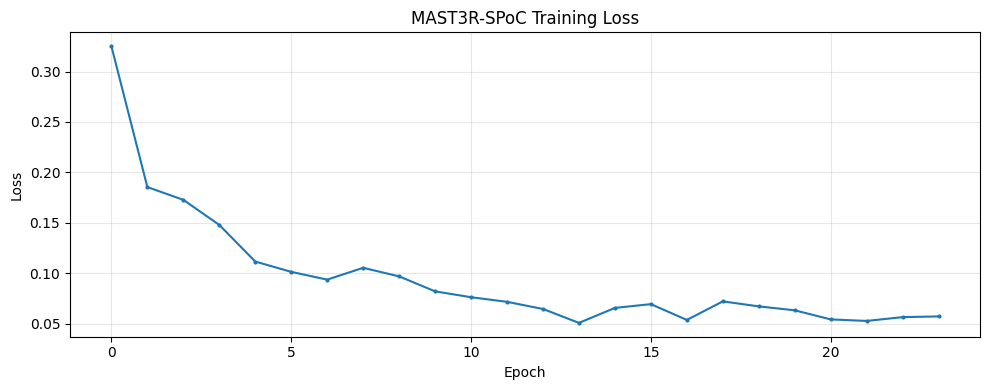

In [7]:
plt.figure(figsize=(10, 4))
plt.plot(history['train_loss'], marker='o', markersize=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('MAST3R-SPoC Training Loss')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(CHECKPOINT_DIR, 'training_curve.png'), dpi=150)
plt.show()

## 8. 全局描述子推理函数

用于后续 Phase 2 图像检索时批量提取 SPoC 描述子。

In [8]:
@torch.no_grad()
def extract_spoc_descriptors(backbone, spoc_head, image_paths, transform, batch_size=16):
    """
    批量提取 SPoC 全局描述子

    Args:
        backbone: MAST3R backbone
        spoc_head: SPoC projection head
        image_paths: list of image paths
        transform: preprocessing transform
        batch_size: inference batch size
    Returns:
        descriptors: (N, 256) L2-normalized descriptors
    """
    backbone.eval()
    spoc_head.eval()
    descriptors = []

    for i in range(0, len(image_paths), batch_size):
        batch_paths = image_paths[i:i + batch_size]
        imgs = []
        for p in batch_paths:
            im = Image.open(p).convert('RGB')
            imgs.append(transform(im).unsqueeze(0))
        x = torch.cat(imgs, dim=0).to(device)
        features = backbone(x)
        desc = spoc_head(features)
        descriptors.append(desc.cpu())

    descriptors = torch.cat(descriptors, dim=0)
    return descriptors


inference_transform = transforms.Compose([
    transforms.Resize(int(IMG_SIZE * 1.14)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


def load_best_spoc_model(checkpoint_dir, backbone, spoc_head, device):
    """加载最佳 checkpoint"""
    ckpt_path = os.path.join(checkpoint_dir, 'best_model.pth')
    if not os.path.exists(ckpt_path):
        raise FileNotFoundError(f'Best model not found at {ckpt_path}')
    ckpt = torch.load(ckpt_path, map_location=device)
    backbone.load_state_dict(ckpt['backbone_state'])
    spoc_head.load_state_dict(ckpt['spoc_head_state'])
    backbone.eval()
    spoc_head.eval()
    print(f'Loaded best model from epoch {ckpt["epoch"]}, loss={ckpt["loss"]:.4f}')
    return backbone, spoc_head


print('Inference functions ready.')

Inference functions ready.
